# Библиотеки

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from config import config

# Чтение данных

In [2]:
train=pd.read_csv(config.paths.data.train)
test=pd.read_csv(config.paths.data.test)

# Статистика
Размер данных


In [3]:
print("Размер обучающей",train.shape)
print("Размер тестовой",test.shape)

Размер обучающей (891, 12)
Размер тестовой (418, 11)


Обзор структуры


In [4]:
print("Обучающая\n")
print(train.info())
print("\n\nТестовая\n")
print(test.info())

Обучающая

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


Тестовая

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass

Описательная статистика численных

In [5]:
print(train.describe().T)

             count        mean         std   min       25%       50%    75%  \
PassengerId  891.0  446.000000  257.353842  1.00  223.5000  446.0000  668.5   
Survived     891.0    0.383838    0.486592  0.00    0.0000    0.0000    1.0   
Pclass       891.0    2.308642    0.836071  1.00    2.0000    3.0000    3.0   
Age          714.0   29.699118   14.526497  0.42   20.1250   28.0000   38.0   
SibSp        891.0    0.523008    1.102743  0.00    0.0000    0.0000    1.0   
Parch        891.0    0.381594    0.806057  0.00    0.0000    0.0000    0.0   
Fare         891.0   32.204208   49.693429  0.00    7.9104   14.4542   31.0   

                  max  
PassengerId  891.0000  
Survived       1.0000  
Pclass         3.0000  
Age           80.0000  
SibSp          8.0000  
Parch          6.0000  
Fare         512.3292  


Описание категориальных

In [6]:
print(train.describe(include=object).T)

         count unique                      top freq
Name       891    891  Braund, Mr. Owen Harris    1
Sex        891      2                     male  577
Ticket     891    681                   347082    7
Cabin      204    147                       G6    4
Embarked   889      3                        S  644


C:\Users\schab\AppData\Local\Temp\ipykernel_4604\3129425579.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(train.describe(include=object).T)


Обзор пропущенных значений и дубликатов

In [7]:
print("Train missing")
print(train.isnull().sum())
print("\n\nTest missing")
print(test.isnull().sum())

print("\n\nTrain duplicates")
print(train.duplicated().sum())
print("\n\nTest duplicates")
print(test.duplicated().sum())

Train missing
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Test missing
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


Train duplicates
0


Test duplicates
0


# Графики
Дисбаланс классов

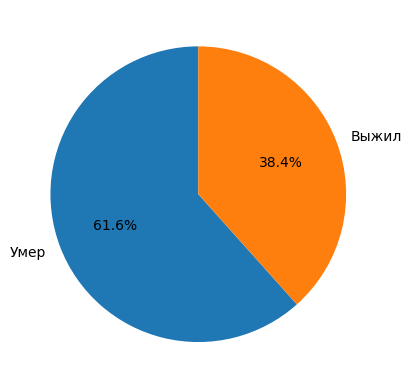

In [8]:
target=train['Survived'].value_counts()
labels=['Умер','Выжил']

plt.pie(target, labels=labels,startangle=90,autopct='%1.1f%%')
plt.show()

## Распределение данных
Возраст


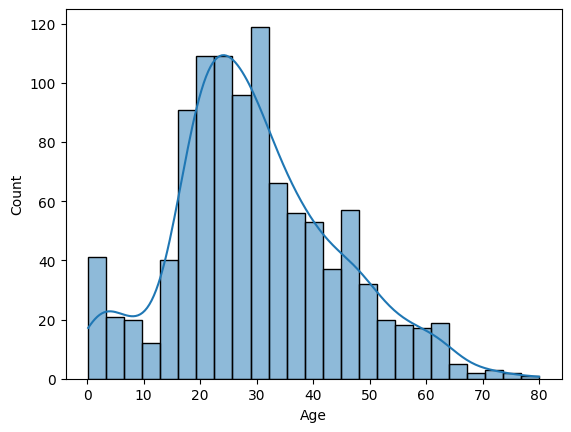

In [9]:
age_data=pd.concat([train['Age'], test['Age']]).dropna()
sns.histplot(age_data,bins=25,kde=True)
plt.show()

Класс билета

Pclass
1    323
2    277
3    709
Name: count, dtype: int64


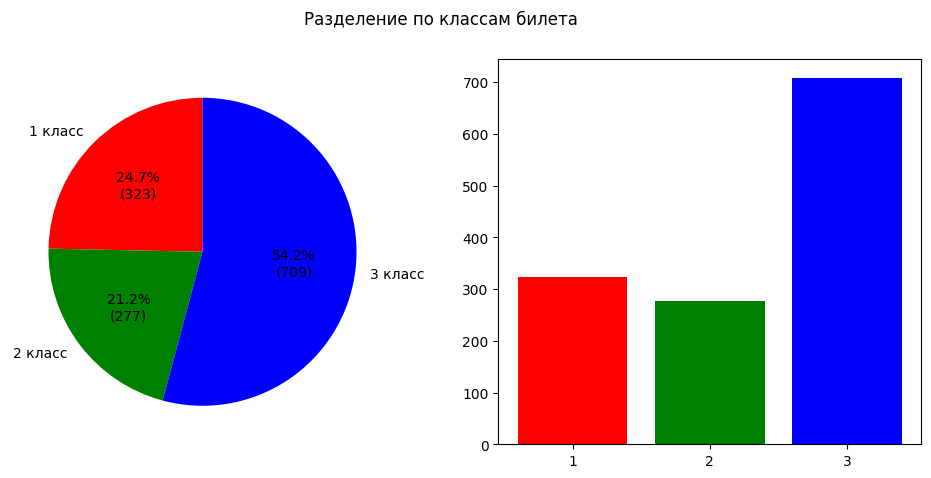

In [10]:
pclass_data=pd.concat([train['Pclass'], test['Pclass']]).dropna().value_counts().sort_index()
print(pclass_data)

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val})'
    return my_format
fig,axes=plt.subplots(1,2,figsize=(12,5))
labels=['1 класс','2 класс','3 класс']
axes[0].pie(pclass_data,labels=labels,startangle=90,autopct = autopct_format(pclass_data),colors=['r','g','b'])
axes[1].bar(pclass_data.index.astype(str),pclass_data.values,color=['r','g','b'])
fig.suptitle('Разделение по классам билета')    
plt.show()

Стоимость билета

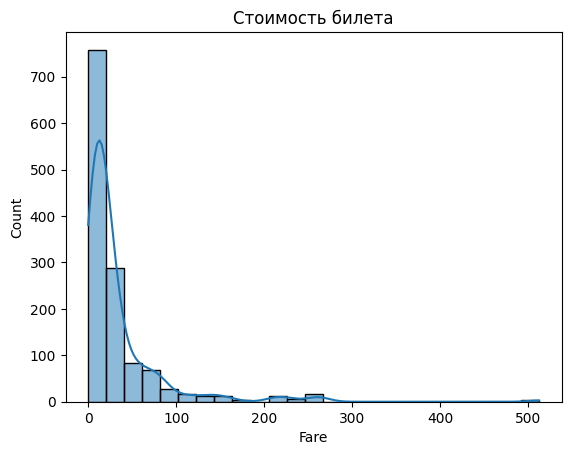

In [11]:
Fare_data = pd.concat([train['Fare'], test['Fare']]).dropna()
sns.histplot(Fare_data,bins=25,kde=True)
plt.title("Стоимость билета")
plt.show()

Распределение полов

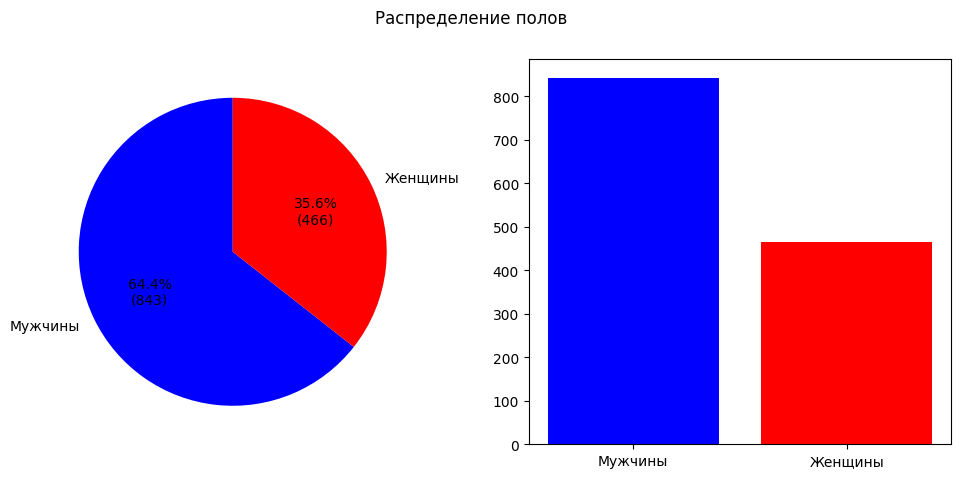

In [12]:
sex_data=pd.concat([train['Sex'],test['Sex']]).dropna().value_counts()
sex_data.rename({"male":"Мужчины","female":"Женщины"},inplace=True)
def autopct_format(values):
    def inner(pct):
        total=sum(values)
        value=int(round(total*pct/100.0))
        return f'{pct:.1f}%\n({value})'
    return inner
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].pie(sex_data,labels=sex_data.index.astype(str),startangle=90,autopct=autopct_format(sex_data),colors=['b','r'])
axes[1].bar(sex_data.index.astype(str),sex_data.values,color=['b','r'])
fig.suptitle("Распределение полов")
plt.show()

Родственные связи

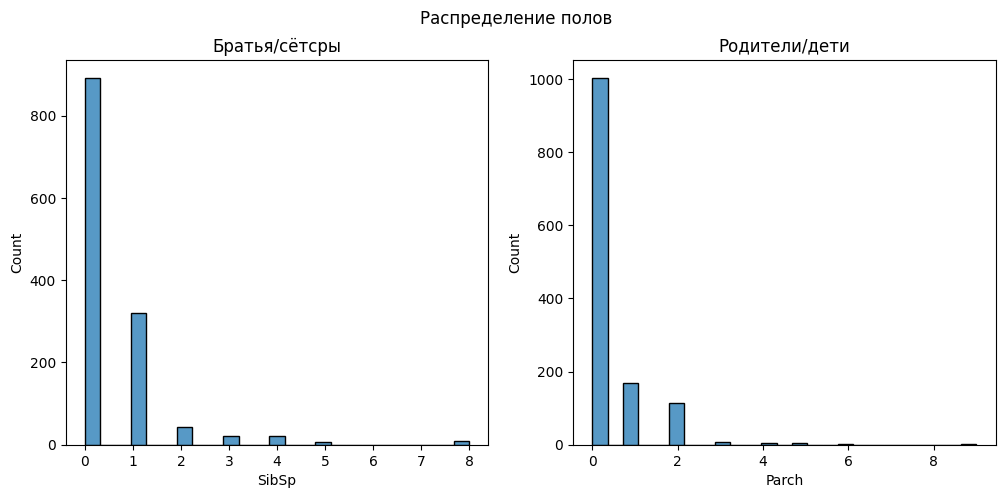

In [13]:
sibsp_data=pd.concat([train['SibSp'],test['SibSp']]).dropna()
parch_data=pd.concat([train['Parch'],test['Parch']]).dropna()
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(sibsp_data,bins=25,ax=axes[0])
axes[0].set_title("Братья/сётсры")
sns.histplot(parch_data,bins=25,ax=axes[1])
axes[1].set_title("Родители/дети")
fig.suptitle("Распределение полов")
plt.show()

Порт посадки


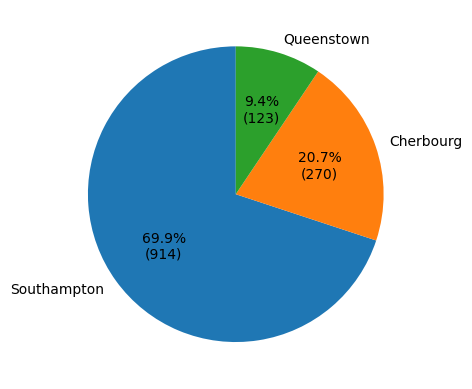

In [14]:
embarked_data=pd.concat([train['Embarked'],test['Embarked']]).dropna().value_counts()
embarked_data.rename({'C':'Cherbourg','Q':'Queenstown','S':'Southampton'},inplace=True)
def my_format(value):
    def inner(pct):
        total=sum(value)
        val=int(round(total*pct/100.0))
        return f'{pct:.1f}%\n({val})'
    return inner
plt.pie(embarked_data,startangle=90,labels=embarked_data.index.astype(str),autopct=my_format(embarked_data))
plt.show()

# Сравнение выживших и переменных
Пол и выживание

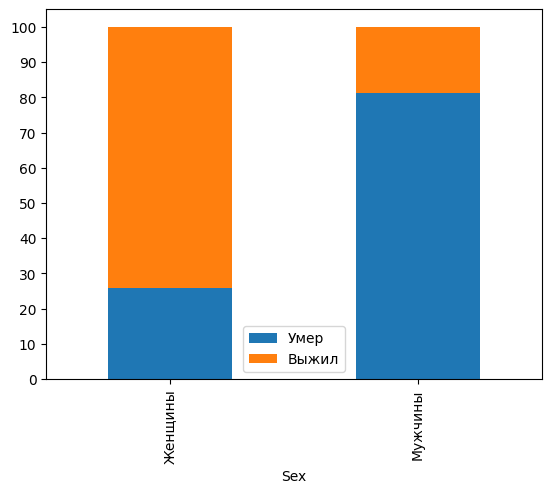

In [15]:
sex_survival=pd.crosstab(train['Sex'],train['Survived'],normalize='index')*100
sex_survival.rename({'male':'Мужчины','female':"Женщины"},inplace=True)
sex_survival.plot(kind="bar",stacked=True,yticks=(0,10,20,30,40,50,60,70,80,90,100))
plt.legend(['Умер','Выжил'],loc='best')
plt.show()

Класс билета и выживаемость

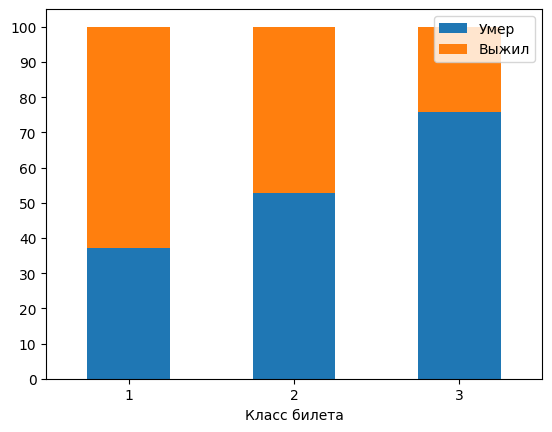

In [16]:
pclass_survival=pd.crosstab(train['Pclass'],train['Survived'],normalize='index')*100
pclass_survival.plot(kind='bar',stacked=True,yticks=(0,10,20,30,40,50,60,70,80,90,100),rot=0,xlabel='Класс билета')
plt.legend(['Умер','Выжил'],loc='best')
plt.show()

Порт и выживание

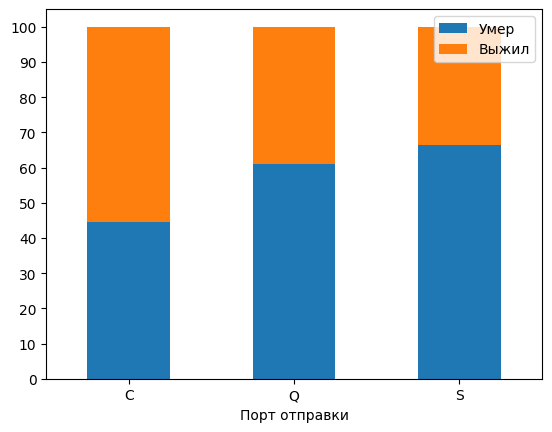

In [17]:
port_survival = pd.crosstab(train['Embarked'],train['Survived'],normalize='index')*100
port_survival.plot(kind='bar',stacked=True,yticks=(0,10,20,30,40,50,60,70,80,90,100),rot=0,xlabel='Порт отправки')
plt.legend(['Умер','Выжил'],loc='best')
plt.show()

Цена  и выживание

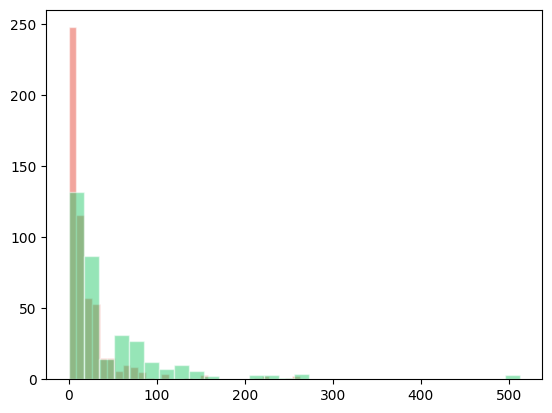

In [18]:
for survived, label, color in [(0, "Died", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    subset = train[train["Survived"] == survived]["Fare"].dropna()
    plt.hist(subset, bins=30, alpha=0.5, color=color, label=label, edgecolor="white")
plt.show()

Возраст и выживание

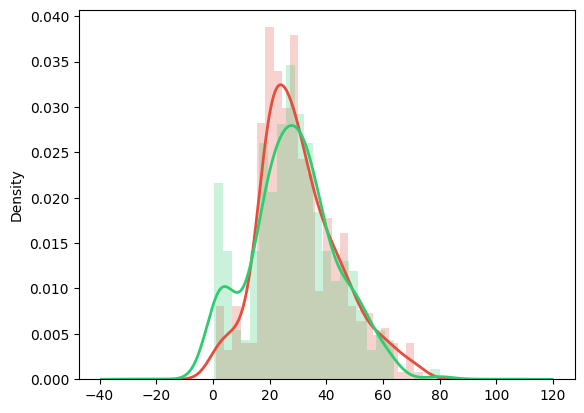

In [19]:
for survived, label, color in [(0, "Died", "#e74c3c"), (1, "Survived", "#2ecc71")]:
    subset = train[train["Survived"] == survived]["Age"].dropna()
    subset.plot.kde(label=label, color=color, linewidth=2)
    plt.hist(subset, bins=25, alpha=0.25, color=color, density=True)
plt.show()

Сёстры/братья и выживание

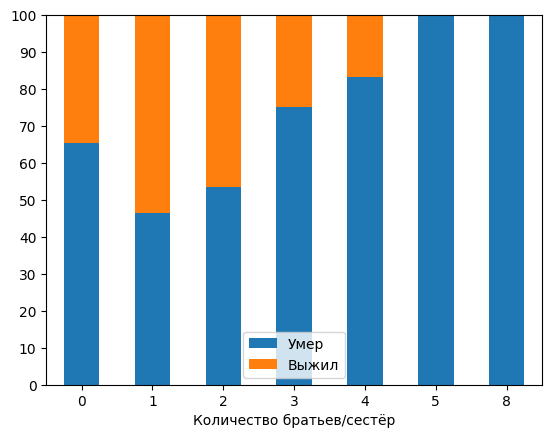

In [20]:
sibsp_survival = pd.crosstab(train['SibSp'],train['Survived'],normalize='index')*100
sibsp_survival.plot(kind='bar',stacked=True,yticks=(0,10,20,30,40,50,60,70,80,90,100),rot=0,xlabel='Количество братьев/сестёр',)
plt.legend(['Умер','Выжил'],loc='best')
plt.show()

Родители и выживание

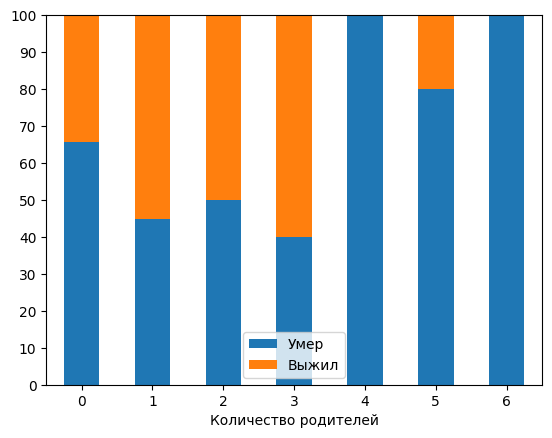

In [21]:
parch_survival = pd.crosstab(train['Parch'],train['Survived'],normalize='index')*100
parch_survival.plot(kind='bar',stacked=True,yticks=(0,10,20,30,40,50,60,70,80,90,100),rot=0,xlabel='Количество родителей')
plt.legend(['Умер','Выжил'],loc='best')
plt.show()

# Корреляционный анализ

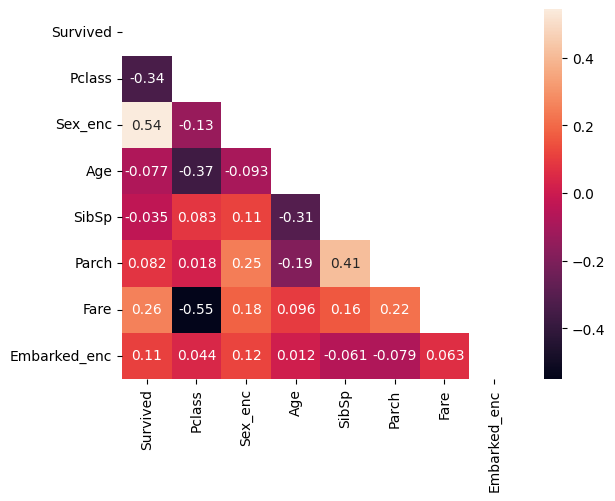

In [22]:
train_corr=train.copy()
train_corr['Sex_enc']=(train_corr['Sex']=='female').astype(int)
train_corr['Embarked_enc']=train_corr['Embarked'].map({'S':0,'C':1,'Q':2})

corr_cols =["Survived","Pclass","Sex_enc","Age","SibSp","Parch","Fare","Embarked_enc"]
corr = train_corr[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,annot=True,mask=mask)
plt.show()

Анализ константных и коррелированных признако

In [23]:
const_cols = [c for c in train.columns if train[c].nunique() <= 1]
print('Константные колонки:', const_cols)

corr = train_corr[corr_cols].corr().abs()
high_corr = [(c, r) for c in corr.columns 
             for r in corr.index 
             if corr.loc[r,c] > 0.85 and c != r]
print('Высокая корреляция:', high_corr)

Константные колонки: []
Высокая корреляция: []


Анализ выбросов

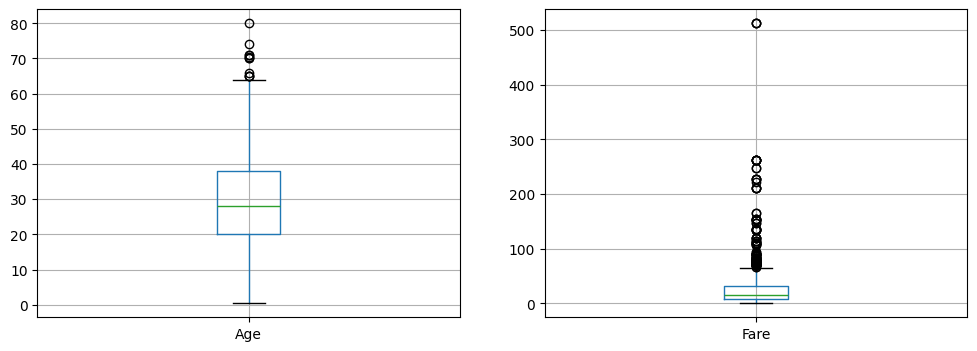

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train.boxplot(column='Age', ax=axes[0])
train.boxplot(column='Fare', ax=axes[1])
plt.show()